# CT-ICH

* Contents

1. Patient Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> 1.4 Patient
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    <br> 2.3 Windowing
    3. Slice level Class
    4. Visualization
    
2. Dataset Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    3. Class
    <br> 3.1 Number of Bleed
    <br> 3.2 Type of Bleed
    <br> 3.3 Volume of Bleed
    4. Visualization

3. nnUNet Dataset 구성
<br> class imbalance 고려

----

In [1]:
import os
from pathlib import Path
from collections import Counter

from scipy import ndimage
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## 1. Patient Unit Analysis

### 1. Basic Info

#### 1. Path

In [2]:
DATA_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data")
DATASET_ROOT = DATA_ROOT / "ct-ich" / "1.3.1"

CT_ROOT = DATASET_ROOT / "ct_scans"
MASK_ROOT = DATASET_ROOT / "masks"
DEMOGRAPHICS_CSV = DATASET_ROOT / "Patient_demographics.csv"
SLICE_LABEL_CSV = DATASET_ROOT / "hemorrhage_diagnosis_raw_ct.csv"

In [50]:
# CT-ICH는 voxel 값이 아니라 CSV 컬럼으로 subtype이 구분됨 (마스크 자체는 binary: 0/255)
class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (0, 255, 255),
}

class_names = {
    1: 'EDH', 
    2: 'IPH', 
    3: 'IVH', 
    4: 'SAH', 
    5: 'SDH'
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

csv_class_columns = ['Intraventricular', 'Intraparenchymal', 'Subarachnoid', 'Epidural', 'Subdural']

In [4]:
slice_df = pd.read_csv(SLICE_LABEL_CSV, encoding='utf-8-sig')

ct_paths = sorted(CT_ROOT.glob("*.nii"))
mask_paths = sorted(MASK_ROOT.glob("*.nii"))
ct_map = {int(p.stem): p for p in ct_paths}
mask_map = {int(p.stem): p for p in mask_paths}
common_patients = sorted(set(ct_map) & set(mask_map))

print("전체 CT 개수:", len(ct_map))
print("전체 마스크 개수:", len(mask_map))
print("Matched Pair:", len(common_patients))
print("CT Only:", sorted(set(ct_map) - set(mask_map)))
print("Mask Only:", sorted(set(mask_map) - set(ct_map)))

전체 CT 개수: 75
전체 마스크 개수: 75
Matched Pair: 75
CT Only: []
Mask Only: []


In [5]:
# .nii 확장자 파일/ import nibabel as nib로 확인해야 함 
patient_key = common_patients[0]
print("선택 환자:", patient_key)

선택 환자: 49


In [6]:
img_nib = nib.load(str(ct_map[patient_key]))
mask_nib = nib.load(str(mask_map[patient_key]))
img_arr = img_nib.get_fdata()
mask_arr = mask_nib.get_fdata()

In [7]:
print(img_nib)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (512, 512, 39)
affine:
[[-4.12109375e-01 -0.00000000e+00  0.00000000e+00  1.05293945e+02]
 [-0.00000000e+00  4.12109375e-01  0.00000000e+00  2.37060547e+01]
 [ 0.00000000e+00 -0.00000000e+00  5.00000000e+00 -6.90500000e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 48
dim             : [  3 512 512  39   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.          0.41210938  0.41210938  5.          0.          0.
  0.          0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units 

In [8]:
print("이미지 shape:", img_arr.shape, "| dtype:", img_nib.get_data_dtype())
print("마스크 shape:", mask_arr.shape, "| dtype:", mask_nib.get_data_dtype())
print("spacing (zooms):", img_nib.header.get_zooms())
print("affine:\n", img_nib.affine)

orient_code = nib.aff2axcodes(img_nib.affine)
print("orientation:", orient_code)

patient_slices = slice_df[slice_df['PatientNumber'] == patient_key].sort_values('SliceNumber')

print("\nCSV 슬라이스 라벨:")
display(patient_slices)

이미지 shape: (512, 512, 39) | dtype: int16
마스크 shape: (512, 512, 39) | dtype: int16
spacing (zooms): (np.float32(0.41210938), np.float32(0.41210938), np.float32(5.0))
affine:
 [[-4.12109375e-01 -0.00000000e+00  0.00000000e+00  1.05293945e+02]
 [-0.00000000e+00  4.12109375e-01  0.00000000e+00  2.37060547e+01]
 [ 0.00000000e+00 -0.00000000e+00  5.00000000e+00 -6.90500000e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
orientation: ('L', 'A', 'S')

CSV 슬라이스 라벨:


,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
0,49,1,0,0,0,0,0,1,0
1,49,2,0,0,0,0,0,1,0
2,49,3,0,0,0,0,0,1,0
3,49,4,0,0,0,0,0,1,0
4,49,5,0,0,0,0,0,1,0
5,49,6,0,0,0,0,0,1,0
6,49,7,0,0,0,0,0,1,0
7,49,8,0,0,0,0,0,1,0
8,49,9,0,0,0,0,0,1,0
9,49,10,0,0,0,0,0,1,0


### 2. 3D CT

#### 2.1 Min/Max

In [9]:
flat = img_arr.astype(np.float32).ravel()
percentiles = np.percentile(flat, [0, 0.5, 1, 5, 50, 95, 99, 99.5, 100])
print("min/max:", flat.min(), flat.max())
print("percentiles:", percentiles)

min/max: -1024.0 2914.0
percentiles: [-1024. -1000.  -999.  -998.  -948.   467.  1208.  1397.  2914.]


#### 2.2 HU

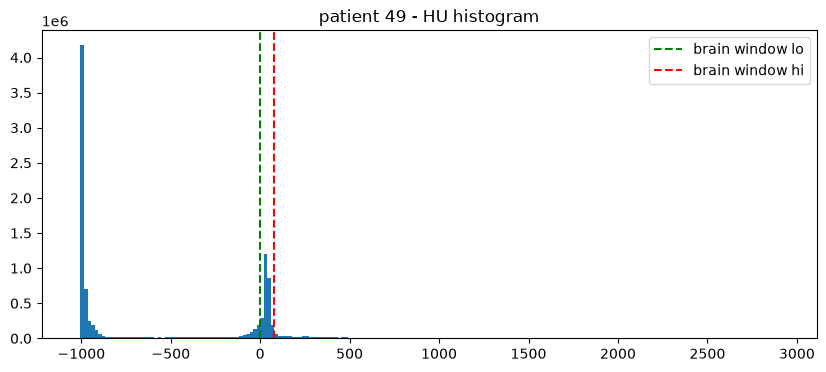

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(flat, bins=200)
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.legend()
plt.title(f'patient {patient_key} - HU histogram')
plt.show()

#### 2.3 Windowing

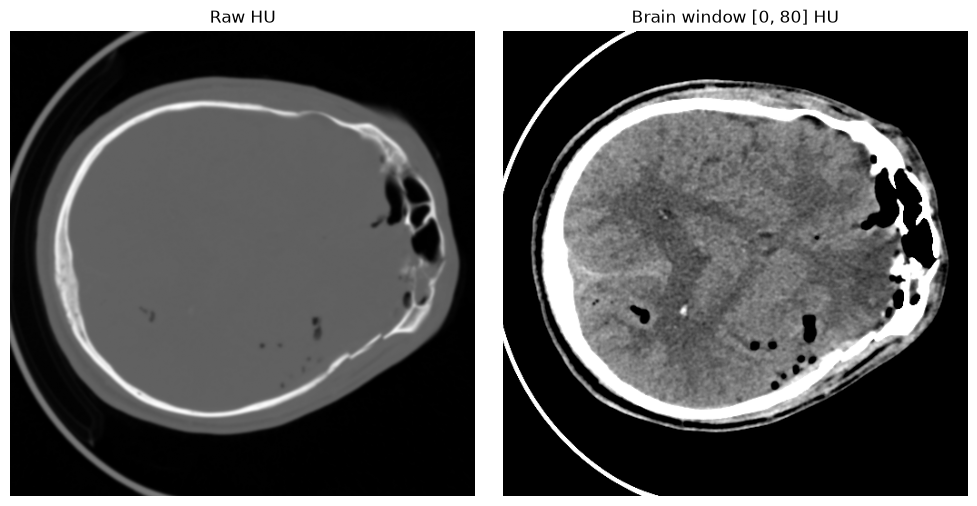

In [11]:
def apply_window(slice_hu, window_level=40, window_width=80):
    lo, hi = window_level - window_width / 2, window_level + window_width / 2
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

num_slices = img_arr.shape[2]
mid = num_slices // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr[:, :, mid], cmap='gray'); axes[0].set_title('Raw HU'); axes[0].axis('off')
axes[1].imshow(apply_window(img_arr[:, :, mid]), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Brain window [0, 80] HU'); axes[1].axis('off')
plt.tight_layout()
plt.show()

### 3. Slice level Class

In [12]:
# mask는 binary라 mask에서 subtype을 못 뽑음 -> CSV에서 슬라이스별 subtype 가져옴
rows = []
for _, row in patient_slices.iterrows():
    z = int(row['SliceNumber']) - 1  # 1-indexed -> 0-indexed
    classes_present = [class_names_1cls[c] for c in csv_class_columns if row[c] == 1]
    fg_voxels = int((mask_arr[:, :, z] > 0).sum()) if 0 <= z < mask_arr.shape[2] else np.nan
    rows.append({
        'slice': z,
        'n_classes': len(classes_present),
        'classes': ', '.join(classes_present),
        'fg_voxels(mask)': fg_voxels,
    })

df_slices = pd.DataFrame(rows)
display(df_slices[df_slices['n_classes'] > 0])

KeyError: 'Epidural'

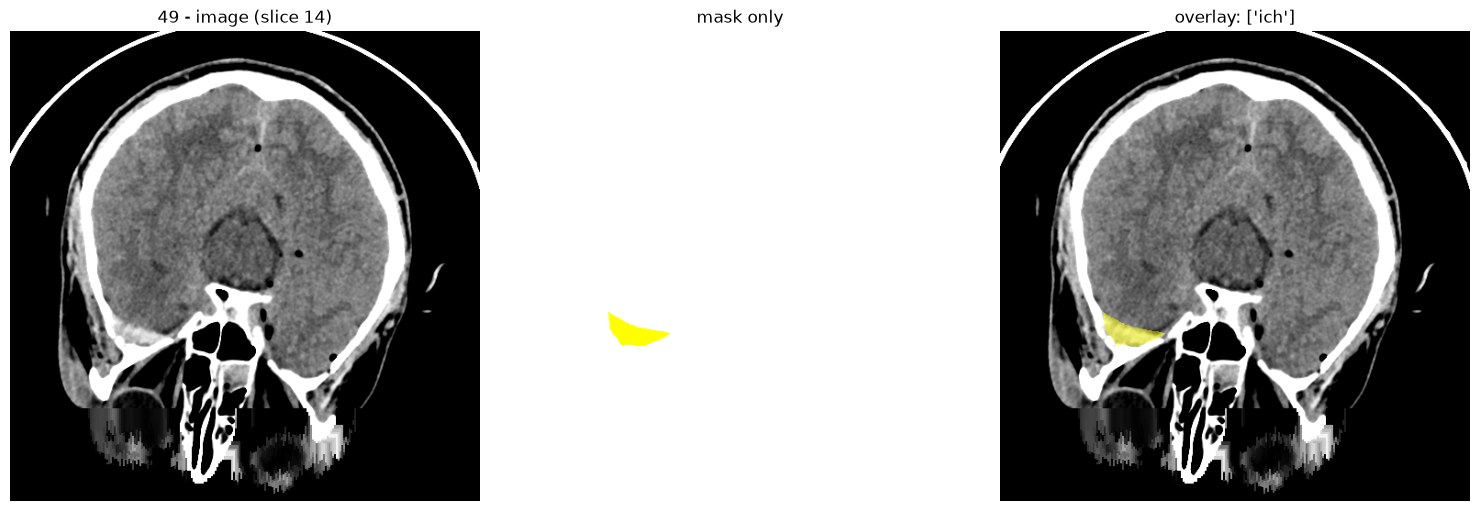

In [ ]:
best_z = int(df_slices['fg_voxels(mask)'].idxmax())
windowed_slice = apply_window(img_arr[:, :, best_z].T)   # [best_z] 아님
mask_slice = mask_arr[:, :, best_z].T                     # [best_z] 아님
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

n_classes_1cls = max(class_colors_1cls.keys()) + 1   # 2 (0, 1)
colors_rgb_1cls = np.zeros((n_classes_1cls, 3))
for cls, rgb in class_colors_1cls.items():
    colors_rgb_1cls[cls] = np.array(rgb) / 255
custom_cmap_1cls = ListedColormap(colors_rgb_1cls)

mask_binary = (mask_slice > 0).astype(int)   # 0/1로 정규화 (원래 255 값이면 정규화가 꼬일 수 있음)
mask_only_display = np.ma.masked_where(mask_binary == 0, mask_binary)
mask_overlay = np.ma.masked_where(mask_binary == 0, mask_binary)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'{patient_key} - image (slice {best_z})')
axes[0].axis('off')

axes[1].set_facecolor('white')
axes[1].imshow(mask_only_display, cmap=custom_cmap_1cls, vmin=0, vmax=1)
axes[1].set_title('mask only')
axes[1].axis('off')

axes[2].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(mask_overlay, cmap=custom_cmap_1cls, alpha=0.5, vmin=0, vmax=1)
present = [class_names_1cls[c] for c in np.unique(mask_binary) if c != 0]
axes[2].set_title(f'overlay: {present}')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### 4. Visualization

In [13]:
from ctviewer import CTViewer
CTViewer(img_arr)

interactive(children=(RadioButtons(description='Slice plane selection:', index=2, options=('y-z', 'z-x', 'x-y'…

## 2. Dataset Unit Analysis

### 1. Basic Info

#### 1.3 Dataset 

In [14]:
meta_rows = []
for pnum in common_patients:
    img = nib.load(str(ct_map[pnum]))
    meta_rows.append({
        'patient': pnum,
        'shape': img.shape,
        'dtype': img.get_data_dtype(),
        'spacing': img.header.get_zooms(),
        'affine_diag': tuple(np.diag(img.affine)[:3]),
        'orientation': nib.aff2axcodes(img.affine),
    })
df_meta = pd.DataFrame(meta_rows)
display(df_meta.head())

print("\n서로 다른 shape 종류 수:", df_meta['shape'].nunique())
print("서로 다른 spacing 종류 수:", df_meta['spacing'].nunique())
print("서로 다른 dtype 종류:", df_meta['dtype'].unique())
print("서로 다른 orientation 종류:", df_meta['orientation'].unique())

,patient,shape,dtype,spacing,affine_diag,orientation
0,49,"(512, 512, 39)",int16,"(0.41210938, 0.41210938, 5.0)","(-0.412109375, 0.412109375, 5.0)","(L, A, S)"
1,50,"(512, 512, 32)",int16,"(0.3515625, 0.3515625, 5.0)","(-0.3515625, 0.3515625, 5.0)","(L, A, S)"
2,51,"(512, 512, 46)",int16,"(0.41210938, 0.41210938, 5.0)","(-0.412109375, 0.412109375, 5.0)","(L, A, S)"
3,52,"(512, 512, 35)",int16,"(0.390625, 0.390625, 5.0)","(-0.390625, 0.390625, 5.0)","(L, A, S)"
4,53,"(512, 512, 35)",int16,"(0.47265625, 0.47265625, 5.0)","(-0.47265625, 0.47265625, 5.0)","(L, A, S)"



서로 다른 shape 종류 수: 19
서로 다른 spacing 종류 수: 35
서로 다른 dtype 종류: [dtype('<i2')]
서로 다른 orientation 종류: [('L', 'A', 'S')]


### 2. 3D CT

#### 2.1 Min/Max

In [15]:
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

hu_rows = []
for pnum in common_patients:
    arr = nib.load(str(ct_map[pnum])).get_fdata().astype(np.float32)
    flat = arr.ravel()
    p = np.percentile(flat, [0.5, 1, 5, 50, 95, 99, 99.5])
    hu_rows.append({
        'patient': pnum, 'min': flat.min(), 'max': flat.max(),
        'p0.5': p[0], 'p1': p[1], 'p5': p[2], 'p50': p[3], 'p95': p[4], 'p99': p[5], 'p99.5': p[6],
    })
df_hu = pd.DataFrame(hu_rows)
display(df_hu.describe())

,patient,min,max,p0.5,p1,p5,p50,p95,p99,p99.5
count,75.00,75.00,75.00,75.00,75.00,75.00,75.00,75.00,75.00,75.00
mean,92.07,-1022.44,2702.00,-1001.44,-1000.60,-999.08,-944.08,442.41,1077.80,1223.16
std,23.29,2.47,390.49,1.44,1.36,1.24,47.80,204.03,251.83,243.70
min,49.00,-1024.00,1713.00,-1005.00,-1003.00,-1001.00,-992.00,62.00,396.00,551.00
25%,74.50,-1024.00,2412.00,-1002.00,-1002.00,-1000.50,-971.50,283.00,932.50,1067.00
50%,93.00,-1024.00,2848.00,-1001.00,-1000.00,-999.00,-962.00,419.00,1114.00,1253.00
75%,111.50,-1021.00,3040.00,-1000.00,-999.00,-998.00,-931.50,572.00,1276.50,1415.50
max,130.00,-1014.00,3071.00,-999.00,-999.00,-998.00,-739.00,916.00,1559.00,1646.00


#### 2.2 HU

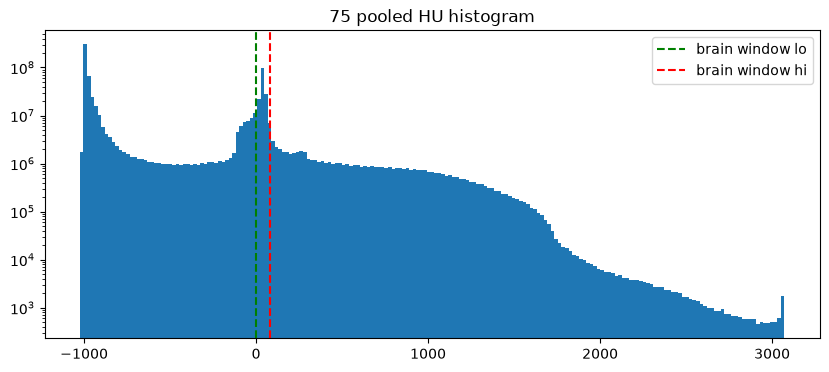

In [17]:
bin_edges = np.linspace(-1024, 3072, 200)
hist_total = np.zeros(len(bin_edges) - 1)
for pnum in common_patients:
    arr = nib.load(str(ct_map[pnum])).get_fdata().astype(np.float32)
    counts, _ = np.histogram(arr.ravel(), bins=bin_edges)
    hist_total += counts

plt.figure(figsize=(10, 4))
plt.bar(bin_edges[:-1], hist_total, width=np.diff(bin_edges), align='edge')
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.yscale('log')
plt.legend()
plt.title(f'{len(common_patients)} pooled HU histogram')
plt.show()

### 3. Class

#### 3.1 Number of Bleed

In [18]:
slice_df_valid = slice_df[slice_df['PatientNumber'].isin(common_patients)].copy()
slice_df_valid['n_classes'] = slice_df_valid[csv_class_columns].sum(axis=1)

slice_bleed_counter = Counter(slice_df_valid['n_classes'])
scan_n_classes = slice_df_valid.groupby('PatientNumber')[csv_class_columns].max().sum(axis=1)
scan_bleed_counter = Counter((scan_n_classes > 0).astype(int) * scan_n_classes.astype(int))
# 위 줄 대신 명확하게:
scan_n_classes = (slice_df_valid.groupby('PatientNumber')[csv_class_columns].max() > 0).sum(axis=1)
scan_bleed_counter = Counter(scan_n_classes)

df_num_bleeds = pd.DataFrame({
    'n_classes co-occurring': range(6),
    'slice count': [slice_bleed_counter.get(n, 0) for n in range(6)],
    'scan count': [scan_bleed_counter.get(n, 0) for n in range(6)],
})
display(df_num_bleeds)

,n_classes co-occurring,slice count,scan count
0,0,2496,39
1,1,293,23
2,2,24,10
3,3,1,2
4,4,0,1
5,5,0,0


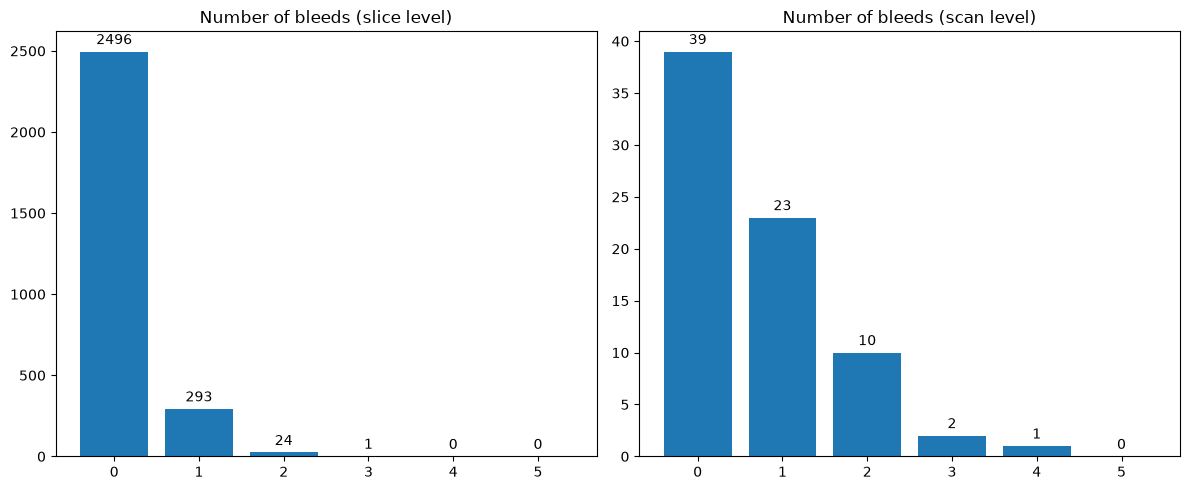

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = list(range(6))
bars0 = axes[0].bar(x, df_num_bleeds['slice count'])
axes[0].set_title('Number of bleeds (slice level)'); axes[0].bar_label(bars0, padding=3)
bars1 = axes[1].bar(x, df_num_bleeds['scan count'])
axes[1].set_title('Number of bleeds (scan level)'); axes[1].bar_label(bars1, padding=3)
plt.tight_layout()
plt.show()

#### 3.2 Type of Bleed

,type,slice count,scan count
0,EDH,173,21
1,IPH,73,16
2,IVH,24,5
3,SAH,18,7
4,SDH,56,4


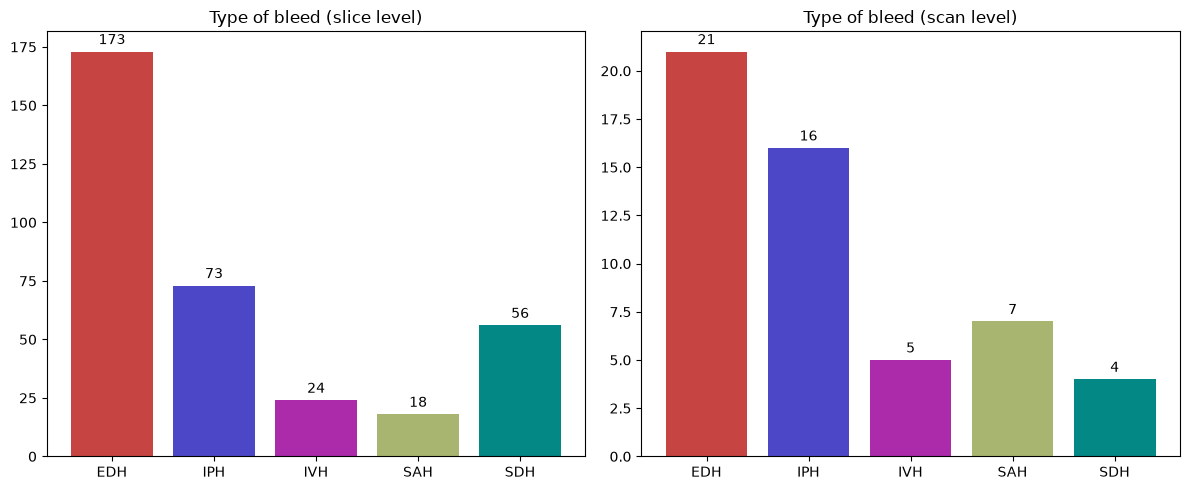

In [37]:
csv_to_short = {
    'Intraventricular': 'IVH',
    'Intraparenchymal': 'IPH',
    'Subarachnoid': 'SAH',
    'Epidural': 'EDH',
    'Subdural': 'SDH',
}
class_colors_short = {
    'EDH': (198, 68, 66),
    'IPH': (76, 71, 199),
    'IVH': (171, 43, 171),
    'SAH': (168, 181, 112),
    'SDH': (4, 136, 133),
}

desired_order = ['EDH', 'IPH', 'IVH', 'SAH', 'SDH']

slice_type_counts = slice_df_valid[csv_class_columns].sum()
scan_type_presence = (slice_df_valid.groupby('PatientNumber')[csv_class_columns].max() > 0).sum()

df_type_bleed = pd.DataFrame({
    'type': [csv_to_short[c] for c in csv_class_columns],
    'slice count': slice_type_counts.values,
    'scan count': scan_type_presence.values,
})
df_type_bleed = df_type_bleed.set_index('type').loc[desired_order].reset_index()  # 순서 고정
display(df_type_bleed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = [np.array(class_colors_short[t]) / 255 for t in df_type_bleed['type']]
bars0 = axes[0].bar(df_type_bleed['type'], df_type_bleed['slice count'], color=colors)
axes[0].set_title('Type of bleed (slice level)'); axes[0].bar_label(bars0, padding=3)
bars1 = axes[1].bar(df_type_bleed['type'], df_type_bleed['scan count'], color=colors)
axes[1].set_title('Type of bleed (scan level)'); axes[1].bar_label(bars1, padding=3)
plt.tight_layout()
plt.show()


#### 3.3 Volume of Bleed

In [ ]:
# 주의: mask가 binary라 subtype별 volume은 원칙적으로 계산 불가.
# "한 슬라이스에 subtype이 정확히 1개"인 경우에만 근사적으로 그 subtype의 volume으로 카운트.

lesion_sizes_mm3 = {c: [] for c in csv_class_columns}

for pnum in common_patients:
    img = nib.load(str(ct_map[pnum]))
    mask = nib.load(str(mask_map[pnum])).get_fdata()
    spacing = img.header.get_zooms()
    voxel_volume_mm3 = float(np.prod(spacing))

    p_slices = slice_df_valid[slice_df_valid['PatientNumber'] == pnum].sort_values('SliceNumber').reset_index(drop=True)
    for i, row in p_slices.iterrows():
        active = [c for c in csv_class_columns if row[c] == 1]
        if len(active) != 1 or i >= mask.shape[2]:
            continue
        fg = int((mask[:, :, i] > 0).sum())
        if fg > 0:
            lesion_sizes_mm3[active[0]].append(fg * voxel_volume_mm3)

rows = []
for c in csv_class_columns:
    sizes = np.array(lesion_sizes_mm3[c])
    rows.append({
        'type': csv_to_short[c],
        'n_single_label_slices': len(sizes),
        'mean_mm3': sizes.mean() if len(sizes) else np.nan,
        'median_mm3': np.median(sizes) if len(sizes) else np.nan,
        'max_mm3': sizes.max() if len(sizes) else np.nan,
    })
df_volume = pd.DataFrame(rows)
display(df_volume)

,type,n_single_label_slices,mean_mm3,median_mm3,max_mm3
0,IVH,13,643.54,595.46,1160.73
1,IPH,52,1085.44,514.03,7683.82
2,SAH,9,1013.35,1096.85,1493.67
3,EDH,167,1377.06,917.10,7614.14
4,SDH,52,3237.23,2428.63,9610.22


#### 3.4 Class Weight

In [41]:
total_scan_labeled = scan_type_presence.sum()
class_weights = {
    csv_to_short[c]: total_scan_labeled / (scan_type_presence[c] * 5)
    for c in csv_class_columns
}
print("scan 등장 빈도 역가중치 기반 class weight:", class_weights)

scan 등장 빈도 역가중치 기반 class weight: {'IVH': np.float64(2.12), 'IPH': np.float64(0.6625), 'SAH': np.float64(1.5142857142857142), 'EDH': np.float64(0.5047619047619047), 'SDH': np.float64(2.65)}


### 4. Visualization

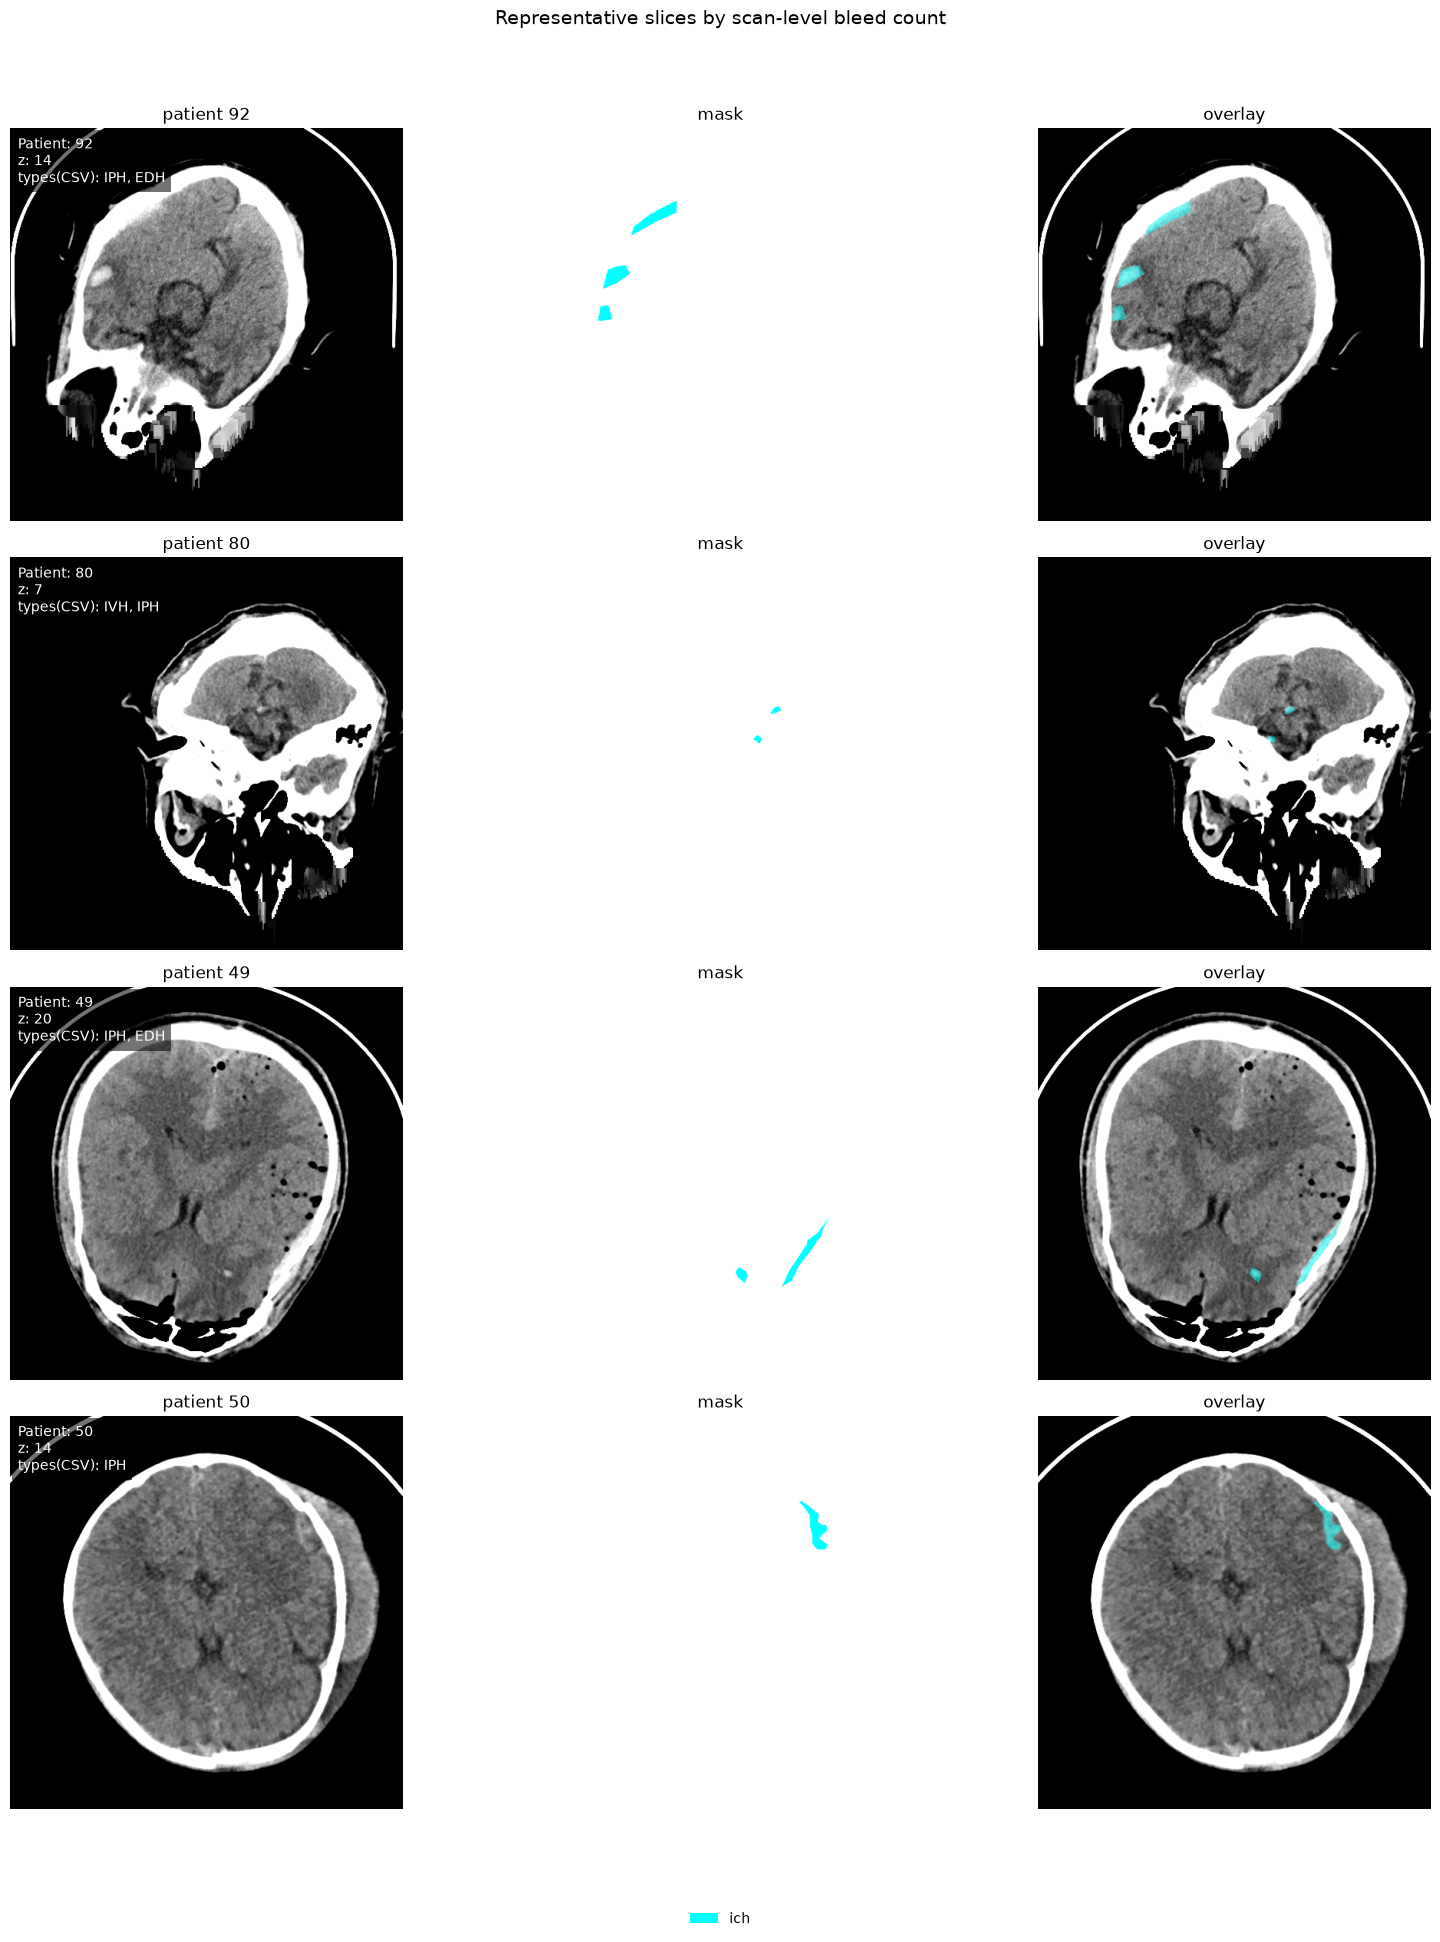

In [51]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

# Build custom colormap (binary: 0=background, 1=ich)
n_classes_1cls = max(class_colors_1cls.keys()) + 1
colors_rgb_1cls = np.zeros((n_classes_1cls, 3))
for cls, rgb in class_colors_1cls.items():
    colors_rgb_1cls[cls] = np.array(rgb) / 255.0
custom_cmap_1cls = ListedColormap(colors_rgb_1cls)

fig, axes = plt.subplots(len(selected), 3, figsize=(16, 4.8 * len(selected)))
if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in enumerate(selected):
    pnum, z = row['patient'], int(row['best_z'])

    img = nib.load(str(ct_map[pnum])).get_fdata()
    mask = nib.load(str(mask_map[pnum])).get_fdata()
    image_slice = apply_window(img[:, :, z].T)
    mask_slice = (mask[:, :, z] > 0).astype(int).T
    mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
    mask_only_display = np.ma.masked_where(mask_slice == 0, mask_slice)

    # 이 슬라이스의 실제 subtype (CSV 기반, 텍스트 표시용)
    row_csv = slice_df_valid[
        (slice_df_valid['PatientNumber'] == pnum) & (slice_df_valid['SliceNumber'] == z + 1)
    ]
    active_types = [csv_to_short[c] for c in csv_class_columns if row_csv[c].max() == 1] if not row_csv.empty else []

    axes[i, 0].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title(f"patient {pnum}")
    axes[i, 0].axis("off")
    axes[i, 0].text(
        0.02, 0.98,
        f"Patient: {pnum}\nz: {z}\ntypes(CSV): {', '.join(active_types) if active_types else '-'}",
        transform=axes[i, 0].transAxes,
        va="top", ha="left", fontsize=10, color="white",
        bbox=dict(facecolor="black", alpha=0.55, edgecolor="none", pad=4),
    )

    axes[i, 1].set_facecolor("black")
    axes[i, 1].imshow(mask_only_display, cmap=custom_cmap_1cls, vmin=0, vmax=1)
    axes[i, 1].set_title("mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    axes[i, 2].imshow(mask_overlay, cmap=custom_cmap_1cls, alpha=0.5, vmin=0, vmax=1)
    axes[i, 2].set_title("overlay")
    axes[i, 2].axis("off")

legend_handles = [
    Patch(facecolor=np.array(class_colors_1cls[c]) / 255.0, edgecolor="none", label=class_names_1cls[c])
    for c in sorted(class_colors_1cls) if c != 0
]

fig.suptitle("Representative slices by scan-level bleed count", y=0.995, fontsize=14)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()


## 3. nnUNet Dataset

In [52]:
import json
import shutil
import random
from pathlib import Path

# 75명(matched pair)만 대상 -> common_patients 사용
patients = sorted(common_patients)
n_patients = len(patients)

rng = random.Random(42)
shuffled = patients[:]
rng.shuffle(shuffled)

n_val = round(n_patients * 0.2)   # 4:1 = 80:20
val_patients = sorted(shuffled[:n_val])
train_patients = sorted(shuffled[n_val:])

print(f"전체 환자: {n_patients}")
print(f"train: {len(train_patients)}, test(val): {len(val_patients)}")

전체 환자: 75
train: 60, test(val): 15


In [53]:
NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")
DATASET_ID = 5
DATASET_NAME = f"Dataset{DATASET_ID:03d}_CTICH_1cls"

DATASET_DIR = NNUNET_ROOT / "nnUNet_raw" / DATASET_NAME
imagesTr = DATASET_DIR / "imagesTr"
labelsTr = DATASET_DIR / "labelsTr"
imagesTs = DATASET_DIR / "imagesTs"
labelsTs = DATASET_DIR / "labelsTs"
for d in (imagesTr, labelsTr, imagesTs, labelsTs):
    d.mkdir(parents=True, exist_ok=True)

for pnum in train_patients:
    cid = f"ctich_{pnum:03d}"
    shutil.copy2(ct_map[pnum], imagesTr / f"{cid}_0000.nii")
    shutil.copy2(mask_map[pnum], labelsTr / f"{cid}.nii")

for pnum in val_patients:
    cid = f"ctich_{pnum:03d}"
    shutil.copy2(ct_map[pnum], imagesTs / f"{cid}_0000.nii")
    shutil.copy2(mask_map[pnum], labelsTs / f"{cid}.nii")

dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {"background": 0, "ich": 1},
    "numTraining": len(train_patients),
    "file_ending": ".nii",
}
with open(DATASET_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print(f"Train(Tr): {len(train_patients)}, Test(Ts): {len(val_patients)}")
print("dataset.json:", DATASET_DIR / "dataset.json")

Train(Tr): 60, Test(Ts): 15
dataset.json: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_raw/Dataset005_CTICH_1cls/dataset.json


In [ ]:
# 